# Experiment 02a: Positive Score Comparison — Trimmed vs Corrected

**Related issue**: [molass-library #4](https://github.com/biosaxs-dev/molass-library/issues/4)  
**Question**: Does `corrected_copy()` (baseline correction) increase `positive_ratio` per frame,
and is this the cause of the increased positive scores in the Guinier report?

**Hypothesis** (from source analysis):  
`positive_ratio` for each frame = weighted fraction of q-points where `I > 0`.  
Baseline correction shifts intensities upward, converting formerly-negative values to positive,  
which mechanically increases `positive_ratio` → `positive_score` → overall Guinier quality score.

## Method
1. Build trimmed (uncorrected) and corrected SSD from SAMPLE1
2. For each frame j, compute `positive_ratio` from `xr.M[:,j]`
3. Plot and compare per-frame `positive_ratio` across both datasets
4. Check whether the shift correlates with the elution profile (more pronounced at tails?)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from molass import get_version
assert get_version() >= '0.7.5', f"Need molass >= 0.7.5, got {get_version()}"

from molass_data import SAMPLE1
from molass.DataObjects import SecSaxsData as SSD

ssd = SSD(SAMPLE1)
trimmed = ssd.trimmed_copy()
corrected = trimmed.corrected_copy()

print(f"molass version: {get_version()}")
print(f"Trimmed  XR matrix shape: {trimmed.xr.M.shape}")
print(f"Corrected XR matrix shape: {corrected.xr.M.shape}")


zeros at the angular ends of error data have been replaced with the adjacent values.


molass version: 0.8.5
Trimmed  XR matrix shape: (984, 241)
Corrected XR matrix shape: (984, 241)


## `positive_ratio` function

This replicates `AdapterQualiy.compute_positive_ratio()` from  
`molass_legacy/GuinierAnalyzer/AutorgKekAdapter.py`.  
It takes a single frame's intensity vector I(q) and returns the weighted fraction of points where I > 0.


In [3]:
def compute_positive_ratio(I):
    """
    Weighted fraction of q-points where I > 0.
    Replicated from AdapterQualiy.compute_positive_ratio() in
    molass_legacy/GuinierAnalyzer/AutorgKekAdapter.py.
    Higher-intensity points get higher weight (simulates importance weighting).
    """
    N = I.shape[0]
    y05, y95 = np.percentile(I, [5, 95])
    if y05 > 0:
        dy = (y95 - y05) / (N - 1)
        weights = np.arange(y95, y05 - dy / 10, -dy)
    else:
        weights = np.ones(N)
    assert weights.shape[0] == N
    weights /= np.sum(weights)
    return np.sum(weights[I > 0])

def compute_ratios_for_matrix(M):
    """Compute positive_ratio for every frame (column) in XR matrix M."""
    return np.array([compute_positive_ratio(M[:, j]) for j in range(M.shape[1])])

ratios_trimmed   = compute_ratios_for_matrix(trimmed.xr.M)
ratios_corrected = compute_ratios_for_matrix(corrected.xr.M)

frames = trimmed.xr.jv  # original frame numbers

print(f"Trimmed   positive_ratio: mean={ratios_trimmed.mean():.4f}, min={ratios_trimmed.min():.4f}, max={ratios_trimmed.max():.4f}")
print(f"Corrected positive_ratio: mean={ratios_corrected.mean():.4f}, min={ratios_corrected.min():.4f}, max={ratios_corrected.max():.4f}")
print(f"Mean increase: {(ratios_corrected - ratios_trimmed).mean():+.4f}")


Trimmed   positive_ratio: mean=0.6266, min=0.4624, max=0.9888
Corrected positive_ratio: mean=0.7158, min=0.5315, max=0.9958
Mean increase: +0.0892


## Plot: per-frame `positive_ratio` before and after baseline correction


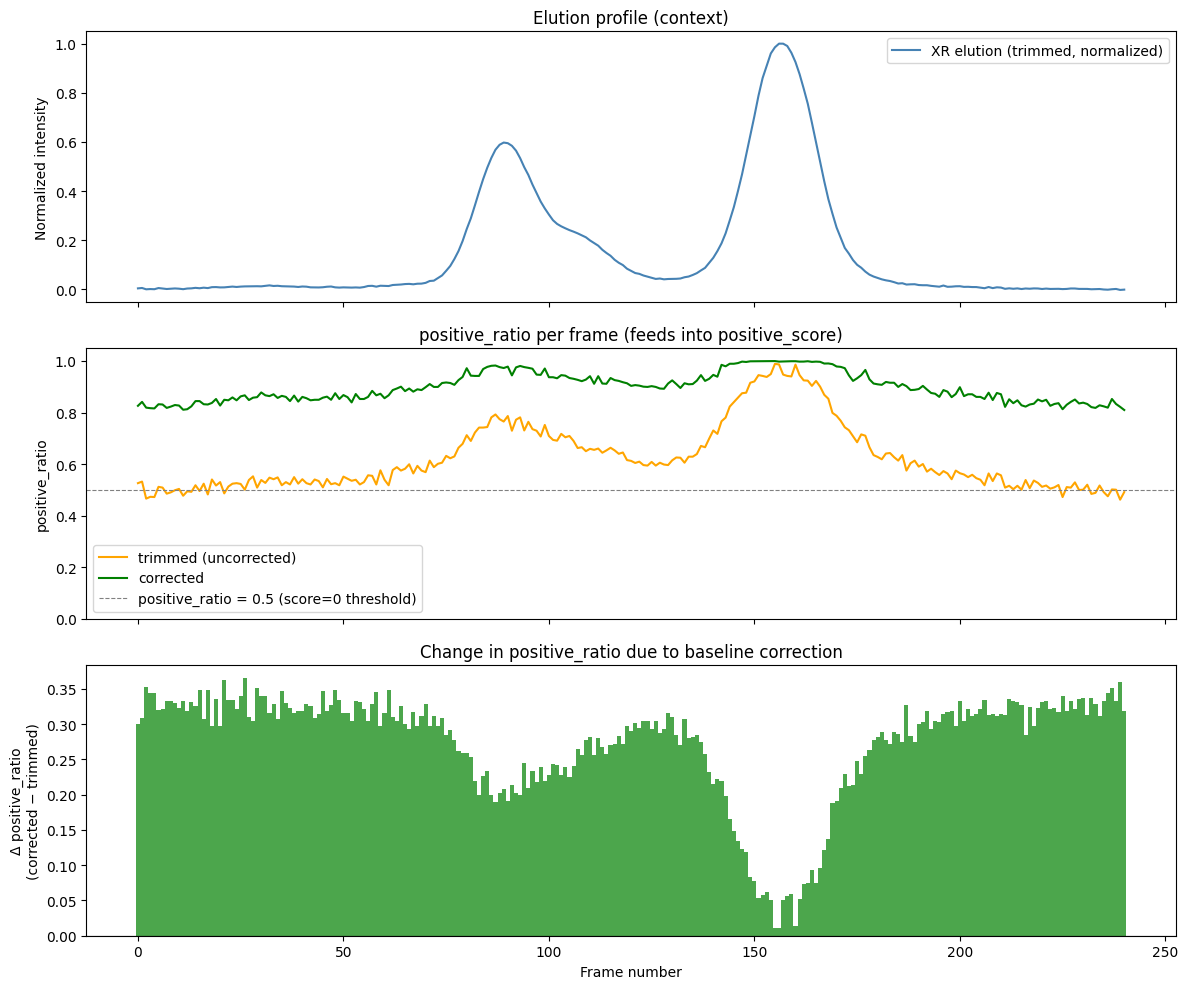

Saved: 02a_positive_ratio_comparison.png


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Panel 1: elution curve (UV or XR) as context
xr_elution = trimmed.xr.M.sum(axis=0)
axes[0].plot(frames, xr_elution / xr_elution.max(), color='steelblue', label='XR elution (trimmed, normalized)')
axes[0].set_ylabel('Normalized intensity')
axes[0].set_title('Elution profile (context)')
axes[0].legend()

# Panel 2: positive_ratio per frame
axes[1].plot(frames, ratios_trimmed,   color='orange',  label='trimmed (uncorrected)', linewidth=1.5)
axes[1].plot(frames, ratios_corrected, color='green',   label='corrected',             linewidth=1.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='positive_ratio = 0.5 (score=0 threshold)')
axes[1].set_ylabel('positive_ratio')
axes[1].set_title('positive_ratio per frame (feeds into positive_score)')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

# Panel 3: difference
diff = ratios_corrected - ratios_trimmed
axes[2].bar(frames, diff, color=np.where(diff > 0, 'green', 'red'), width=1.0, alpha=0.7)
axes[2].axhline(0, color='k', linewidth=0.8)
axes[2].set_ylabel('Δ positive_ratio\n(corrected − trimmed)')
axes[2].set_xlabel('Frame number')
axes[2].set_title('Change in positive_ratio due to baseline correction')

fig.tight_layout()
plt.savefig('02a_positive_ratio_comparison.png', dpi=150)
plt.show()
print("Saved: 02a_positive_ratio_comparison.png")


## What baseline correction does to the intensity at a specific frame

To understand *why* positive_ratio changes, let's look at the q-profile (I vs q) for a  
representative frame — one from the tail region where the effect is likely largest.


Frame with largest Δpositive_ratio: frame 26 (col index 26), Δ=+0.3659
Peak frame: frame 156 (col index 156)


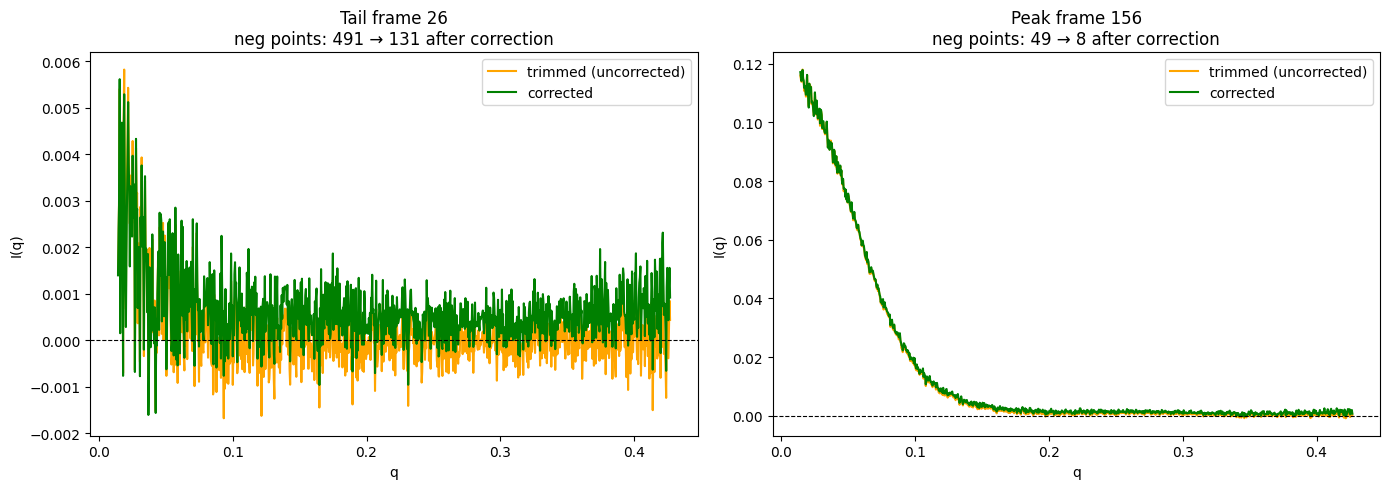

Saved: 02a_iq_profiles.png


In [4]:
# Pick the frame with the largest positive_ratio increase
diff = ratios_corrected - ratios_trimmed
tail_idx = np.argmax(diff)
tail_frame = frames[tail_idx]
print(f"Frame with largest Δpositive_ratio: frame {tail_frame} (col index {tail_idx}), Δ={diff[tail_idx]:+.4f}")

# Also pick the peak frame for comparison
peak_idx = np.argmax(xr_elution)
peak_frame = frames[peak_idx]
print(f"Peak frame: frame {peak_frame} (col index {peak_idx})")

qv = trimmed.xr.qv

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, idx, label in [(axes[0], tail_idx, f'Tail frame {tail_frame}'),
                        (axes[1], peak_idx, f'Peak frame {peak_frame}')]:
    I_trim = trimmed.xr.M[:, idx]
    I_corr = corrected.xr.M[:, idx]
    ax.plot(qv, I_trim, label='trimmed (uncorrected)', color='orange', linewidth=1.5)
    ax.plot(qv, I_corr, label='corrected',             color='green',  linewidth=1.5)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel('q')
    ax.set_ylabel('I(q)')
    ax.set_title(label)
    ax.legend()
    n_neg_trim = np.sum(I_trim <= 0)
    n_neg_corr = np.sum(I_corr <= 0)
    ax.set_title(f"{label}\nneg points: {n_neg_trim} → {n_neg_corr} after correction")

fig.tight_layout()
plt.savefig('02a_iq_profiles.png', dpi=150)
plt.show()
print("Saved: 02a_iq_profiles.png")


## Summary

Fill in after running the notebook:

| Metric | Trimmed (uncorrected) | Corrected |
|--------|-----------------------|-----------|
| Mean positive_ratio | | |
| Frames where ratio > 0.5 | | |
| Frames where ratio < 0.1 (effectively rejected) | | |

**Interpretation**:
- If the increase is concentrated in the tails (low-signal frames), it reflects the legacy data having residual negative baseline artifacts there — and the correction is physically justified.
- If the increase affects peak frames too, examine whether the correction is overcorrecting signal-rich regions.


## What does `corrected_copy()` actually subtract?

The library's baseline correction (`get_baseline2d()`) fits an LPM (Linear Plus Minimum) baseline  
**along q** for each frame independently, using `ScatteringBaseline` from molass-legacy.  

For a peak frame this is fine — it removes a slowly-varying background.  
For a tail frame with pure noise, the LPM fitter finds a small gradient and lifts the whole profile.

Plot: the baseline surface itself vs the elution profile.


baseline2d shape: (984, 241)  (n_q x n_frames)


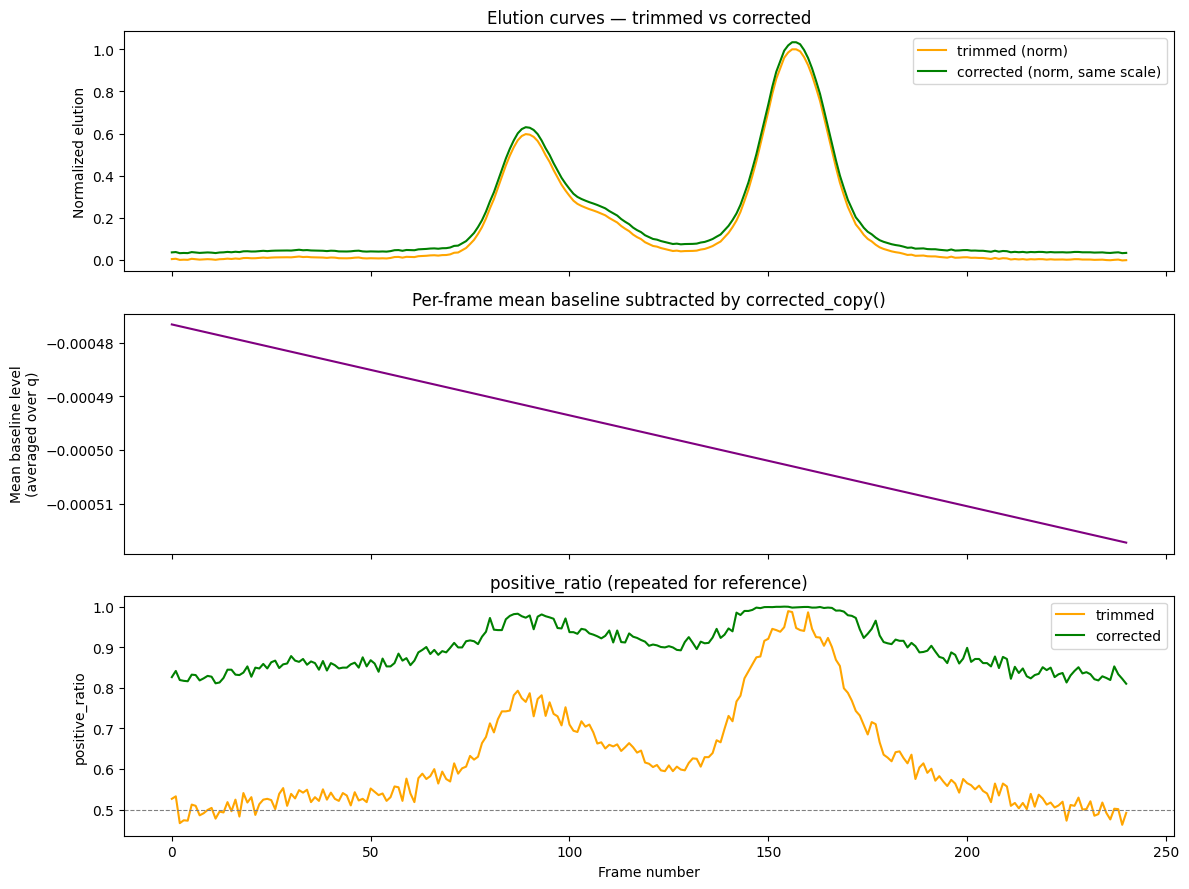

Saved: 02a_baseline2d_inspection.png


In [5]:
# Retrieve the 2D baseline that corrected_copy() subtracts from xr.M
baseline2d = trimmed.xr.get_baseline2d()   # shape: (n_q, n_frames)
print(f"baseline2d shape: {baseline2d.shape}  (n_q x n_frames)")

# The baseline is subtracted row-by-row from M:
#   corrected.xr.M = trimmed.xr.M - baseline2d
# Let's look at the per-frame mean baseline level (averaged over q)
baseline_mean_per_frame = baseline2d.mean(axis=0)

# Compare to trimmed and corrected elution curves
xr_elution_corrected = corrected.xr.M.sum(axis=0)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(frames, xr_elution / xr_elution.max(), color='orange', label='trimmed (norm)')
axes[0].plot(frames, xr_elution_corrected / xr_elution.max(), color='green', label='corrected (norm, same scale)')
axes[0].set_ylabel('Normalized elution')
axes[0].set_title('Elution curves — trimmed vs corrected')
axes[0].legend()

axes[1].plot(frames, baseline_mean_per_frame, color='purple')
axes[1].set_ylabel('Mean baseline level\n(averaged over q)')
axes[1].set_title('Per-frame mean baseline subtracted by corrected_copy()')

axes[2].plot(frames, ratios_trimmed,   color='orange', label='trimmed', linewidth=1.5)
axes[2].plot(frames, ratios_corrected, color='green',  label='corrected', linewidth=1.5)
axes[2].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_ylabel('positive_ratio')
axes[2].set_xlabel('Frame number')
axes[2].set_title('positive_ratio (repeated for reference)')
axes[2].legend()

fig.tight_layout()
plt.savefig('02a_baseline2d_inspection.png', dpi=150)
plt.show()
print("Saved: 02a_baseline2d_inspection.png")


## Where does LPM anchor its fit? Low-percentile frames in a q-row

`ScatteringBaseline.solve()` operates along the **frame axis** for each q-value independently.  
It iteratively finds the lowest-percentile intensity frames and fits a line through them.  

If those anchor frames happen to have slightly negative intensities (buffer noise),  
the fit line ends up below zero → negative baseline → positive shift after subtraction.

Visualize: for a representative q-row, show the data across frames and mark which frames  
fall below the 25th percentile (the initial LPM anchor set).


Examining q = 0.2210 (index 492)
  row min=-0.00119, max=0.00173, mean=0.00009
  25th percentile threshold: -0.00025
  Number of anchor frames: 61 / 241
  Anchor frames negative count: 61
  Anchor frames min value: -0.00119

LPM fit: slope=-0.000000, intercept=-0.000504
  Baseline at frame 0: -0.00050
  Baseline at frame 240: -0.00051
  Baseline is negative throughout: True


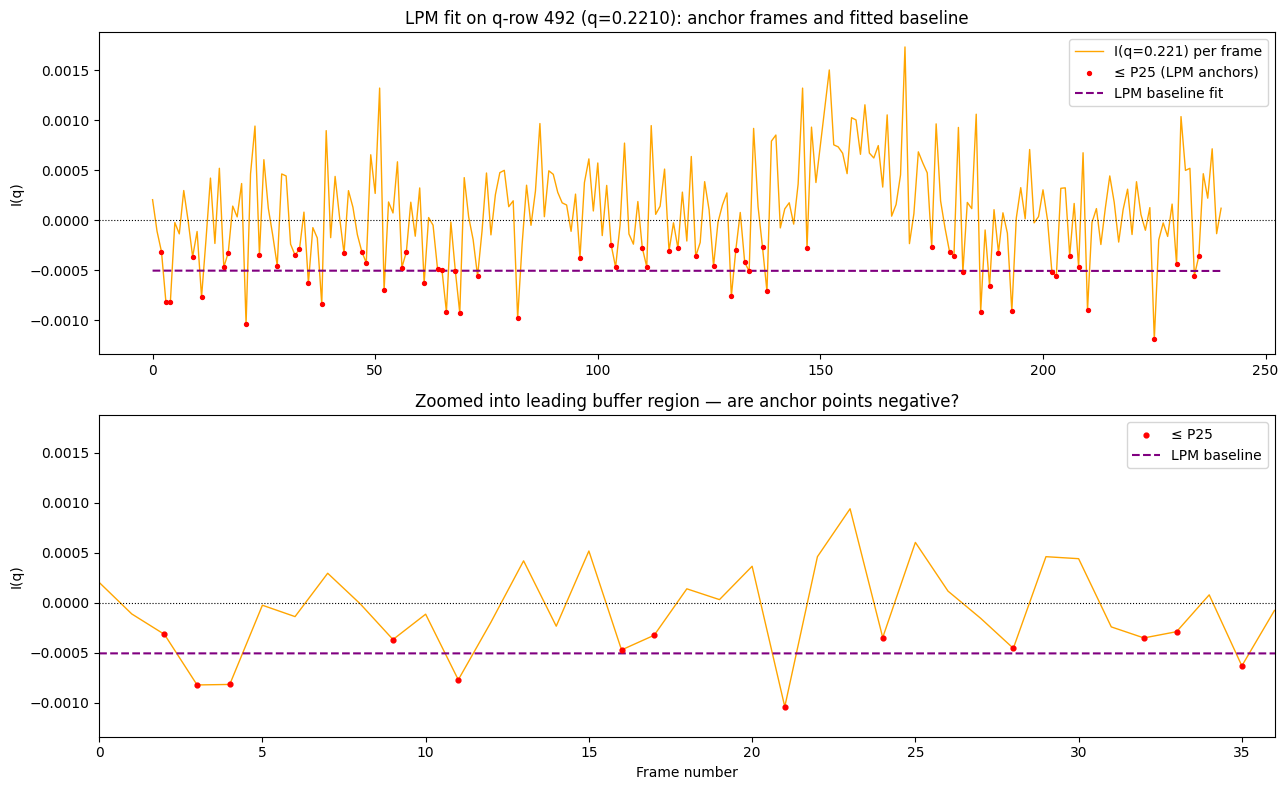

Saved: 02a_lpm_anchor_inspection.png


In [7]:
from molass_legacy.Baseline.ScatteringBaseline import ScatteringBaseline, PERCENTILE_FIRST

# Pick a mid-q row (not too small-angle, not too high-q) to examine
q_idx = len(qv) // 2
q_val = qv[q_idx]
row = trimmed.xr.M[q_idx, :]   # intensity at this q across all frames

print(f"Examining q = {q_val:.4f} (index {q_idx})")
print(f"  row min={row.min():.5f}, max={row.max():.5f}, mean={row.mean():.5f}")

# Compute the first-pass percentile threshold (PERCENTILE_FIRST = 25 by default)
p25 = np.percentile(row, PERCENTILE_FIRST)
anchor_mask = row <= p25
anchor_frames = frames[anchor_mask]
anchor_vals   = row[anchor_mask]

print(f"  25th percentile threshold: {p25:.5f}")
print(f"  Number of anchor frames: {anchor_mask.sum()} / {len(row)}")
print(f"  Anchor frames negative count: {(anchor_vals < 0).sum()}")
print(f"  Anchor frames min value: {anchor_vals.min():.5f}")

# Fit the LPM baseline on this row explicitly
sbl = ScatteringBaseline(row, x=frames)
slope, intercept = sbl.solve()
lpm_line = frames * slope + intercept

print(f"\nLPM fit: slope={slope:.6f}, intercept={intercept:.6f}")
print(f"  Baseline at frame {frames[0]}: {lpm_line[0]:.5f}")
print(f"  Baseline at frame {frames[-1]}: {lpm_line[-1]:.5f}")
print(f"  Baseline is negative throughout: {(lpm_line < 0).all()}")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(frames, row, color='orange', linewidth=1, label=f'I(q={q_val:.3f}) per frame')
axes[0].scatter(anchor_frames, anchor_vals, color='red', s=8, zorder=5, label=f'≤ P{PERCENTILE_FIRST} (LPM anchors)')
axes[0].plot(frames, lpm_line, color='purple', linewidth=1.5, linestyle='--', label='LPM baseline fit')
axes[0].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('I(q)')
axes[0].set_title(f'LPM fit on q-row {q_idx} (q={q_val:.4f}): anchor frames and fitted baseline')
axes[0].legend()

# Zoom into the buffer-frame region to see the anchor values
tail_end = frames[int(len(frames)*0.15)]
axes[1].plot(frames, row, color='orange', linewidth=1)
axes[1].scatter(anchor_frames, anchor_vals, color='red', s=12, zorder=5, label=f'≤ P{PERCENTILE_FIRST}')
axes[1].plot(frames, lpm_line, color='purple', linewidth=1.5, linestyle='--', label='LPM baseline')
axes[1].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[1].set_xlim(frames[0], tail_end)
axes[1].set_ylabel('I(q)')
axes[1].set_xlabel('Frame number')
axes[1].set_title('Zoomed into leading buffer region — are anchor points negative?')
axes[1].legend()

fig.tight_layout()
plt.savefig('02a_lpm_anchor_inspection.png', dpi=150)
plt.show()
print("Saved: 02a_lpm_anchor_inspection.png")


## Does passing `curve=` (with peak info) change the LPM result?

`ScatteringBaseline` has a rescue mechanism in `get_low_percentile_params()`:  
if all the P25-anchor points land **past** the peak's right foot, it retries using only the pre-peak buffer slice.

The question: does this rescue ever trigger for our data, and would it fix the negative-baseline problem?

To test, we construct a minimal mock curve that carries `peak_info` (the only attribute accessed),  
then compare `ScatteringBaseline` results with and without it on the same q-row.


Peak frame: 156
Right foot frame (10% threshold): 175

Without curve:
  slope=-0.000000, intercept=-0.000504
  Anchor xpp[0] = 2.0  (smallest anchor frame)
  Rescue condition xpp[0] > right_foot (175): False

With curve (peak_info rescue enabled):
  slope=-0.000000, intercept=-0.000504
  Anchor xpp[0] = 2.0
  Same result as without curve: True


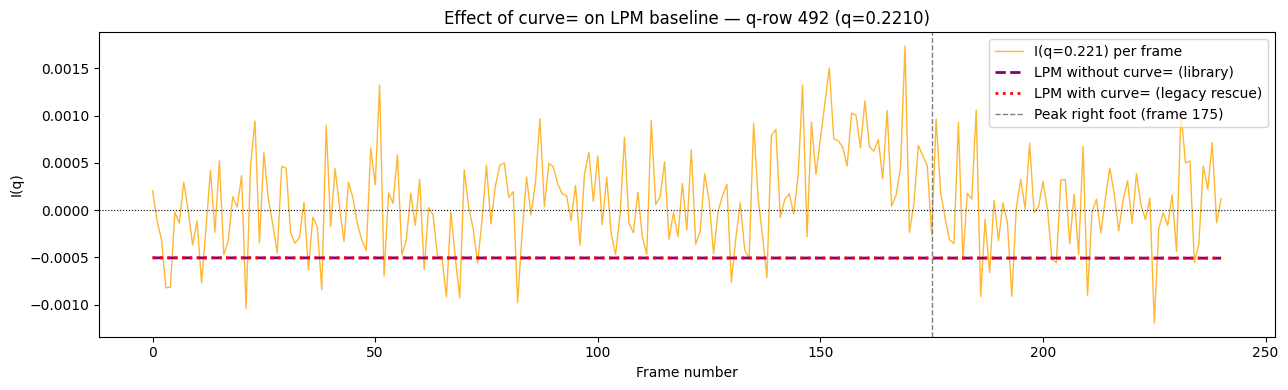

Saved: 02a_curve_effect.png


In [8]:
from types import SimpleNamespace

# --- Estimate peak right foot from the XR elution curve ---
# peak_idx is already known; find where elution drops back to ~10% of peak on the right
peak_height = xr_elution[peak_idx]
threshold = peak_height * 0.1
right_foot_candidates = np.where((frames > peak_frame) & (xr_elution < threshold))[0]
right_foot_idx = right_foot_candidates[0] if len(right_foot_candidates) > 0 else len(frames) - 1
right_foot_frame = frames[right_foot_idx]

print(f"Peak frame: {peak_frame}")
print(f"Right foot frame (10% threshold): {right_foot_frame}")

# Construct a minimal mock curve — ScatteringBaseline only accesses .peak_info[-1][2]
# peak_info entry: [left_foot, top, right_foot]
mock_peak_info = [[int(frames[0]), int(peak_frame), int(right_foot_frame)]]
mock_curve = SimpleNamespace(peak_info=mock_peak_info)

# --- Run LPM without curve (library behaviour) ---
sbl_no_curve = ScatteringBaseline(row, x=frames, suppress_warning=True)
slope_nc, intercept_nc = sbl_no_curve.solve()
xpp_nc = sbl_no_curve.xpp   # anchor x-values after fitting

# --- Run LPM with curve (legacy peak-aware rescue) ---
sbl_curve = ScatteringBaseline(row, x=frames, curve=mock_curve, suppress_warning=True)
slope_wc, intercept_wc = sbl_curve.solve()
xpp_wc = sbl_curve.xpp

# --- Check rescue condition ---
print(f"\nWithout curve:")
print(f"  slope={slope_nc:.6f}, intercept={intercept_nc:.6f}")
print(f"  Anchor xpp[0] = {xpp_nc[0]:.1f}  (smallest anchor frame)")
print(f"  Rescue condition xpp[0] > right_foot ({right_foot_frame}): {xpp_nc[0] > right_foot_frame}")

print(f"\nWith curve (peak_info rescue enabled):")
print(f"  slope={slope_wc:.6f}, intercept={intercept_wc:.6f}")
print(f"  Anchor xpp[0] = {xpp_wc[0]:.1f}")
print(f"  Same result as without curve: {np.isclose(slope_nc, slope_wc) and np.isclose(intercept_nc, intercept_wc)}")

# --- Visualize ---
lpm_nc = frames * slope_nc + intercept_nc
lpm_wc = frames * slope_wc + intercept_wc

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(frames, row, color='orange', linewidth=1, alpha=0.8, label=f'I(q={q_val:.3f}) per frame')
ax.plot(frames, lpm_nc, color='purple', linewidth=2, linestyle='--', label='LPM without curve= (library)')
ax.plot(frames, lpm_wc, color='red',    linewidth=2, linestyle=':',  label='LPM with curve= (legacy rescue)')
ax.axvline(right_foot_frame, color='gray', linewidth=1, linestyle='--', label=f'Peak right foot (frame {right_foot_frame})')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel('Frame number')
ax.set_ylabel('I(q)')
ax.set_title(f'Effect of curve= on LPM baseline — q-row {q_idx} (q={q_val:.4f})')
ax.legend()
fig.tight_layout()
plt.savefig('02a_curve_effect.png', dpi=150)
plt.show()
print("Saved: 02a_curve_effect.png")


## Alternative: pybaseline's native 2D algorithm (`asls`)

`pybaseline.Baseline2D` exposes true 2D penalized least-squares algorithms (`asls`, `iasls`, `aspls`, …)
that fit a smooth surface across **both** axes simultaneously.

Unlike the per-row LPM approach, `asls` in 2D enforces smoothness in q and frame directions at once —
it has no concept of individual row anchoring, so it shouldn't be pulled down by negative noise dips.

Compare: LPM (`method='linear'`) vs. `method='asls'` on the same `M.T` matrix.


Running pybaseline asls 2D fit … (may take a few seconds)
Done.

LPM  baseline mean: -0.00050  (range -0.00052 … -0.00048)
asls baseline mean: -0.00045  (range -0.00086 … -0.00021)

positive_ratio after LPM:  mean=0.8986
positive_ratio after asls: mean=0.9367
positive_ratio trimmed:    mean=0.6266


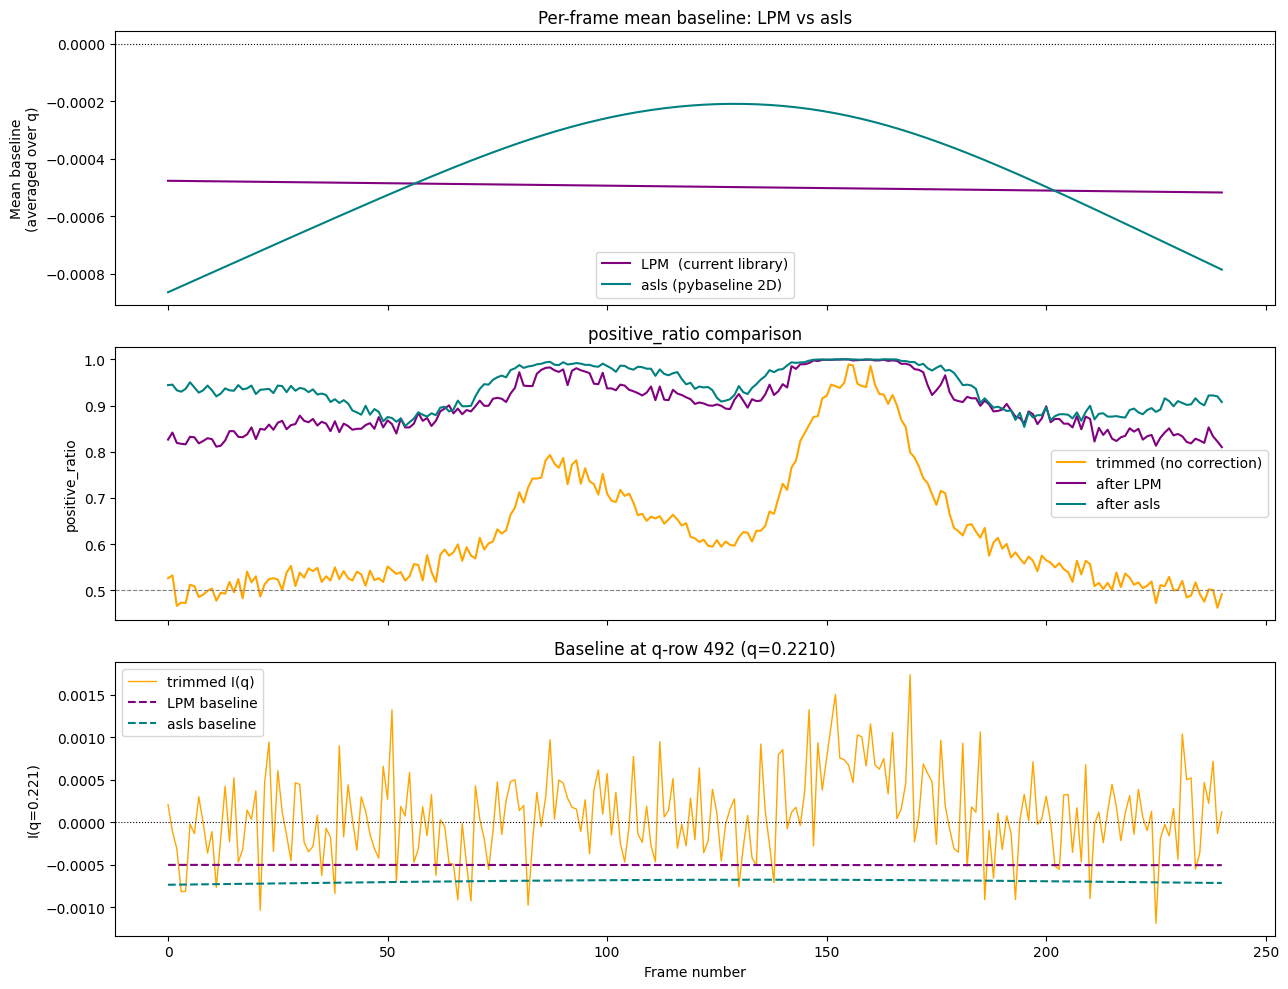

Saved: 02a_asls_vs_lpm.png


In [9]:
from molass.Baseline.Baseline2D import Baseline2D

M = trimmed.xr.M          # shape: (n_q, n_frames)
jv = trimmed.xr.jv        # frame numbers
iv = trimmed.xr.iv        # q values (iv = inverse of q? or just q indices — same as qv)

fitter = Baseline2D(jv, iv)

# --- LPM baseline (current library behaviour) ---
baseline_lpm, _ = fitter.individual_axes(M.T, axes=0, method='linear',
                                          method_kwargs=dict(jv=jv), debug=False)
baseline_lpm = baseline_lpm.T   # back to (n_q, n_frames)

# --- 2D asls baseline ---
print("Running pybaseline asls 2D fit … (may take a few seconds)")
baseline_asls, _ = fitter.asls(M.T)
baseline_asls = baseline_asls.T   # back to (n_q, n_frames)
print("Done.")

# Per-frame mean baseline level
lpm_mean  = baseline_lpm.mean(axis=0)
asls_mean = baseline_asls.mean(axis=0)

print(f"\nLPM  baseline mean: {lpm_mean.mean():.5f}  (range {lpm_mean.min():.5f} … {lpm_mean.max():.5f})")
print(f"asls baseline mean: {asls_mean.mean():.5f}  (range {asls_mean.min():.5f} … {asls_mean.max():.5f})")

# positive_ratio after each correction
M_lpm_corr  = M - baseline_lpm
M_asls_corr = M - baseline_asls

ratios_lpm  = compute_ratios_for_matrix(M_lpm_corr)   # == ratios_corrected
ratios_asls = compute_ratios_for_matrix(M_asls_corr)

print(f"\npositive_ratio after LPM:  mean={ratios_lpm.mean():.4f}")
print(f"positive_ratio after asls: mean={ratios_asls.mean():.4f}")
print(f"positive_ratio trimmed:    mean={ratios_trimmed.mean():.4f}")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(jv, lpm_mean,  color='purple', label='LPM  (current library)')
axes[0].plot(jv, asls_mean, color='teal',   label='asls (pybaseline 2D)')
axes[0].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('Mean baseline\n(averaged over q)')
axes[0].set_title('Per-frame mean baseline: LPM vs asls')
axes[0].legend()

axes[1].plot(jv, ratios_trimmed, color='orange', label='trimmed (no correction)', linewidth=1.5)
axes[1].plot(jv, ratios_lpm,    color='purple',  label='after LPM',               linewidth=1.5)
axes[1].plot(jv, ratios_asls,   color='teal',    label='after asls',              linewidth=1.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('positive_ratio')
axes[1].set_title('positive_ratio comparison')
axes[1].legend()

# q-row at q_idx — compare the two baselines
axes[2].plot(jv, M[q_idx, :],              color='orange', linewidth=1,   label='trimmed I(q)')
axes[2].plot(jv, baseline_lpm[q_idx, :],  color='purple', linewidth=1.5, linestyle='--', label='LPM baseline')
axes[2].plot(jv, baseline_asls[q_idx, :], color='teal',   linewidth=1.5, linestyle='--', label='asls baseline')
axes[2].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[2].set_xlabel('Frame number')
axes[2].set_ylabel(f'I(q={q_val:.3f})')
axes[2].set_title(f'Baseline at q-row {q_idx} (q={q_val:.4f})')
axes[2].legend()

fig.tight_layout()
plt.savefig('02a_asls_vs_lpm.png', dpi=150)
plt.show()
print("Saved: 02a_asls_vs_lpm.png")


## Weight-constrained baseline: fit only on buffer frames

Idea: give the solver a weight array where buffer frames = 1 and peak-region frames ≈ 0.
The solver then fits the baseline to buffer frames only and interpolates through the peak.

We use `pybaselines.Baseline.asls()` (1D, per q-row) with the weight mask.
`asls` minimises $\|w (y - z)\|^2 + \lambda \|D^2 z\|^2$ where $D^2$ is the second-difference operator.
With $w \approx 0$ in the peak region, the fit ignores those frames and smoothly bridges the buffers.

**Buffer mask**: elution < 10 % of peak height.


Buffer frames: 164 / 241  (68%)

positive_ratio — trimmed : 0.6266
positive_ratio — LPM    : 0.8986
positive_ratio — asls   : 0.9367
positive_ratio — w-asls : 0.9306  ← weight-constrained


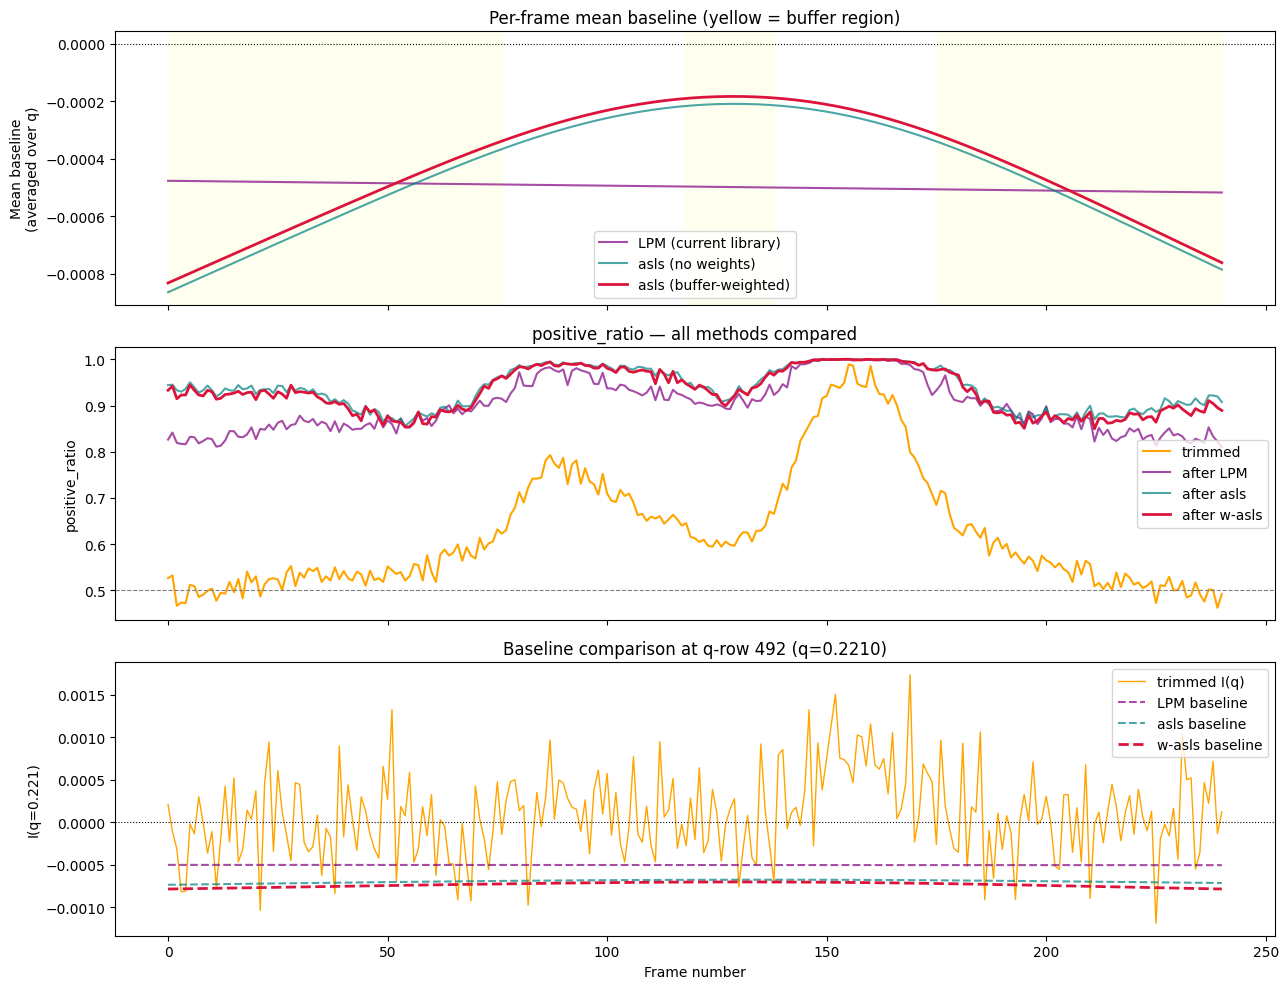

Saved: 02a_weighted_asls.png


In [10]:
import pybaselines

# --- Build buffer-frame weight mask ---
elution_norm = xr_elution / xr_elution.max()
is_buffer = elution_norm < 0.10          # True for frames far from the peak
w_buffer  = np.where(is_buffer, 1.0, 1e-4)   # near-zero weight in peak region

print(f"Buffer frames: {is_buffer.sum()} / {len(frames)}  "
      f"({100*is_buffer.mean():.0f}%)")

# --- Fit weight-constrained asls per q-row ---
lam = 1e6    # smoothness — higher = straighter baseline
p   = 0.01   # asymmetry — small p → baseline hugs the lower envelope

fitter1d = pybaselines.Baseline(x_data=frames)

baseline_w = np.zeros_like(M)
for qi in range(M.shape[0]):
    b, _ = fitter1d.asls(M[qi, :], lam=lam, p=p, weights=w_buffer)
    baseline_w[qi, :] = b

M_w_corr = M - baseline_w
ratios_w  = compute_ratios_for_matrix(M_w_corr)

wbl_mean = baseline_w.mean(axis=0)

print(f"\npositive_ratio — trimmed : {ratios_trimmed.mean():.4f}")
print(f"positive_ratio — LPM    : {ratios_lpm.mean():.4f}")
print(f"positive_ratio — asls   : {ratios_asls.mean():.4f}")
print(f"positive_ratio — w-asls : {ratios_w.mean():.4f}  ← weight-constrained")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

axes[0].plot(jv, lpm_mean,   color='purple', alpha=0.7, label='LPM (current library)')
axes[0].plot(jv, asls_mean,  color='teal',   alpha=0.7, label='asls (no weights)')
axes[0].plot(jv, wbl_mean,   color='crimson',linewidth=2, label='asls (buffer-weighted)')
axes[0].axhline(0, color='k', linewidth=0.8, linestyle=':')
buf_spans = np.where(np.diff(np.concatenate([[False], is_buffer, [False]])))[0].reshape(-1, 2)
for s, e in buf_spans:
    axes[0].axvspan(jv[s] if s < len(jv) else jv[-1],
                    jv[e-1] if e <= len(jv) else jv[-1],
                    color='lightyellow', alpha=0.5)
axes[0].set_ylabel('Mean baseline\n(averaged over q)')
axes[0].set_title('Per-frame mean baseline (yellow = buffer region)')
axes[0].legend()

axes[1].plot(jv, ratios_trimmed, color='orange', label='trimmed',           linewidth=1.5)
axes[1].plot(jv, ratios_lpm,    color='purple',  label='after LPM',         linewidth=1.5, alpha=0.7)
axes[1].plot(jv, ratios_asls,   color='teal',    label='after asls',        linewidth=1.5, alpha=0.7)
axes[1].plot(jv, ratios_w,      color='crimson', label='after w-asls',      linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('positive_ratio')
axes[1].set_title('positive_ratio — all methods compared')
axes[1].legend()

axes[2].plot(jv, M[q_idx, :],              color='orange', linewidth=1,   label='trimmed I(q)')
axes[2].plot(jv, baseline_lpm[q_idx, :],  color='purple', linewidth=1.5, linestyle='--', label='LPM baseline',  alpha=0.7)
axes[2].plot(jv, baseline_asls[q_idx, :], color='teal',   linewidth=1.5, linestyle='--', label='asls baseline', alpha=0.7)
axes[2].plot(jv, baseline_w[q_idx, :],    color='crimson',linewidth=2,   linestyle='--', label='w-asls baseline')
axes[2].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[2].set_xlabel('Frame number')
axes[2].set_ylabel(f'I(q={q_val:.3f})')
axes[2].set_title(f'Baseline comparison at q-row {q_idx} (q={q_val:.4f})')
axes[2].legend()

fig.tight_layout()
plt.savefig('02a_weighted_asls.png', dpi=150)
plt.show()
print("Saved: 02a_weighted_asls.png")


## Which legacy branch actually runs? Simulating `correct_all_q_planes`

With `xray_baseline_type=1` (the normal default), the legacy uses `correct_all_q_planes`,
which runs LPM per q-row **along the frame axis** — the same axis as the library.

Key differences from the library's `get_baseline2d()`:
1. **Adaptive `p_final`**: computed per q-row from noisiness via `base_percentile_offset(noisiness, size_sigma)` — the noisier the q-row, the larger the final percentile offset
2. **`curve=ecurve`** passed to `ScatteringBaseline` — enables the rescue mechanism (though we showed it doesn't trigger for SAMPLE1)
3. **Multiple iterations** (`num_iterations`) for small-angle q-rows

Let's replicate this directly on our q-row to see whether the adaptive `p_final` differs from the library's fixed 10%.


recognize_num_peaks
peak_width= 38
size_sigma = 7.4673  (legacy ScatteringBaseCorrector measure of peak width)

For q-row 492 (q=0.2210):
  noisiness  = 0.000431
  p_final (adaptive, legacy) = 28.56%
  p_final (fixed, library)   = 10%

Adaptive p_final=28.6%: slope=-0.000000, intercept=-0.000216
Fixed    p_final=10%:   slope=-0.000000, intercept=-0.000504
Difference in intercept: +0.000289

p_final across q-rows: min=28.6%  max=28.6%  mean=28.6%

positive_ratio — trimmed     : 0.6266
positive_ratio — library LPM : 0.8986
positive_ratio — legacy sim  : 0.7158  ← adaptive p_final


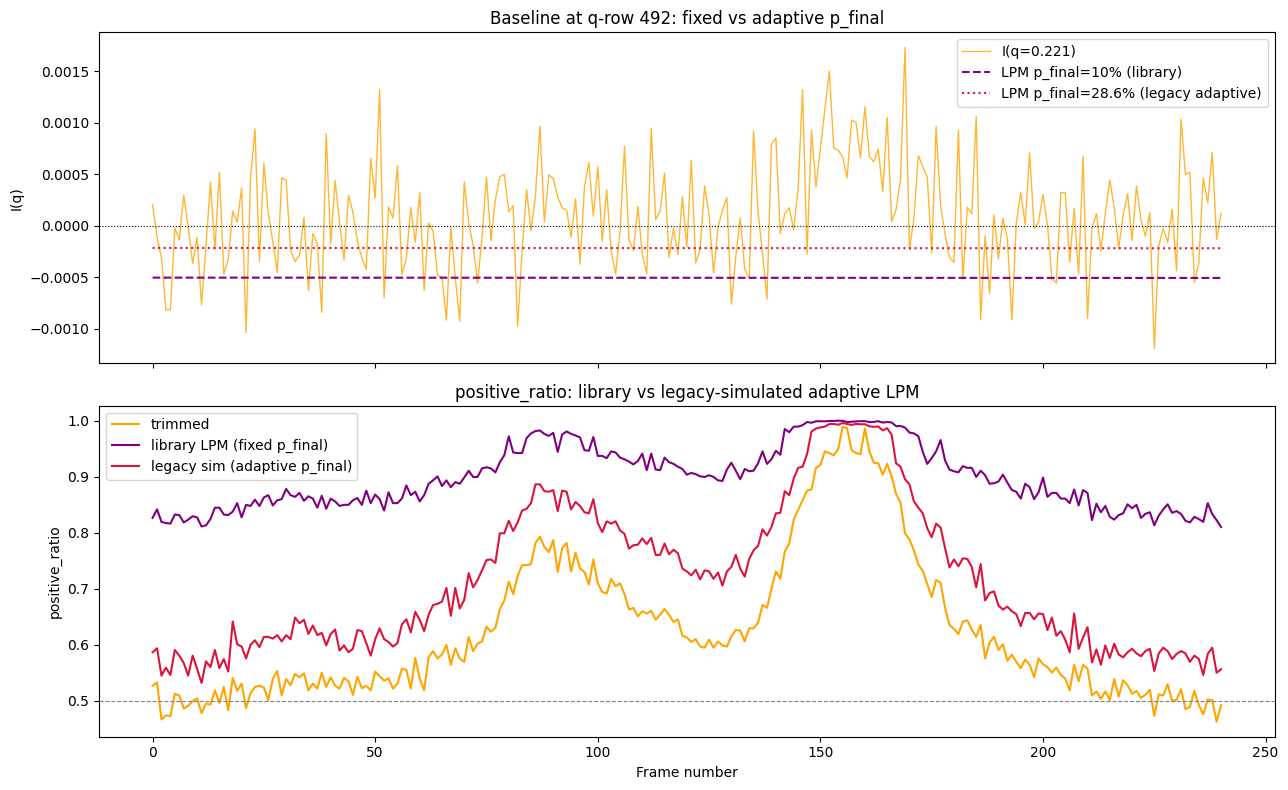

Saved: 02a_adaptive_pfinal.png


In [12]:
from scipy.interpolate import LSQUnivariateSpline
from molass_legacy.SerialAnalyzer.BasePercentileOffset import base_percentile_offset
from molass_legacy.Baseline.ScatteringBaseline import ScatteringBaseline, PERCENTILE_FINAL

# Replicate ScatteringBaseCorrector.__init__ sizing of size_sigma
from molass_legacy.SerialAnalyzer.ElutionBaseCurve import ElutionBaseCurve
ecurve_obj = ElutionBaseCurve(xr_elution)
size_sigma = ecurve_obj.compute_size_sigma()
print(f"size_sigma = {size_sigma:.4f}  (legacy ScatteringBaseCorrector measure of peak width)")

# --- Replicate correct_a_single_q_plane for our q_idx ---
iknots = np.linspace(0, len(frames), len(frames) // 10)[1:-1]
spline = LSQUnivariateSpline(frames, row, iknots)
noisiness = np.std(row - spline(frames))
p_final_adaptive = base_percentile_offset(noisiness, size_sigma=size_sigma)

print(f"\nFor q-row {q_idx} (q={q_val:.4f}):")
print(f"  noisiness  = {noisiness:.6f}")
print(f"  p_final (adaptive, legacy) = {p_final_adaptive:.2f}%")
print(f"  p_final (fixed, library)   = {PERCENTILE_FINAL}%")

# --- Run LPM with adaptive p_final (legacy-style) ---
sbl_adaptive = ScatteringBaseline(row, x=frames, suppress_warning=True)
slope_a, intercept_a = sbl_adaptive.solve(p_final=p_final_adaptive)
baseline_adaptive = frames * slope_a + intercept_a

# --- Run LPM with fixed p_final=10 (library-style) ---
sbl_fixed = ScatteringBaseline(row, x=frames, suppress_warning=True)
slope_f, intercept_f = sbl_fixed.solve(p_final=PERCENTILE_FINAL)
baseline_fixed = frames * slope_f + intercept_f

print(f"\nAdaptive p_final={p_final_adaptive:.1f}%: slope={slope_a:.6f}, intercept={intercept_a:.6f}")
print(f"Fixed    p_final={PERCENTILE_FINAL}%:   slope={slope_f:.6f}, intercept={intercept_f:.6f}")
print(f"Difference in intercept: {intercept_a - intercept_f:+.6f}")

# --- Also compute the adaptive LPM for all q-rows ---
baseline_legacy_sim = np.zeros_like(M)
p_finals = []
for qi in range(M.shape[0]):
    r = M[qi, :]
    knots = np.linspace(0, len(frames), len(frames) // 10)[1:-1]
    sp = LSQUnivariateSpline(frames, r, knots)
    ns = np.std(r - sp(frames))
    pf = base_percentile_offset(ns, size_sigma=size_sigma)
    p_finals.append(pf)
    sbl_q = ScatteringBaseline(r, x=frames, suppress_warning=True)
    sl, ic = sbl_q.solve(p_final=pf)
    baseline_legacy_sim[qi, :] = frames * sl + ic

M_legacy_sim = M - baseline_legacy_sim
ratios_legacy_sim = compute_ratios_for_matrix(M_legacy_sim)

print(f"\np_final across q-rows: min={min(p_finals):.1f}%  max={max(p_finals):.1f}%  mean={np.mean(p_finals):.1f}%")
print(f"\npositive_ratio — trimmed     : {ratios_trimmed.mean():.4f}")
print(f"positive_ratio — library LPM : {ratios_lpm.mean():.4f}")
print(f"positive_ratio — legacy sim  : {ratios_legacy_sim.mean():.4f}  ← adaptive p_final")

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(frames, row, color='orange', linewidth=1, alpha=0.8, label=f'I(q={q_val:.3f})')
axes[0].plot(frames, baseline_fixed,    color='purple', linewidth=1.5, linestyle='--',
             label=f'LPM p_final={PERCENTILE_FINAL}% (library)')
axes[0].plot(frames, baseline_adaptive, color='crimson', linewidth=1.5, linestyle=':',
             label=f'LPM p_final={p_final_adaptive:.1f}% (legacy adaptive)')
axes[0].axhline(0, color='k', linewidth=0.8, linestyle=':')
axes[0].set_ylabel('I(q)')
axes[0].set_title(f'Baseline at q-row {q_idx}: fixed vs adaptive p_final')
axes[0].legend()

axes[1].plot(frames, ratios_trimmed,     color='orange', label='trimmed',            linewidth=1.5)
axes[1].plot(frames, ratios_lpm,         color='purple', label='library LPM (fixed p_final)', linewidth=1.5)
axes[1].plot(frames, ratios_legacy_sim,  color='crimson', label='legacy sim (adaptive p_final)', linewidth=1.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_ylabel('positive_ratio')
axes[1].set_xlabel('Frame number')
axes[1].set_title('positive_ratio: library vs legacy-simulated adaptive LPM')
axes[1].legend()

fig.tight_layout()
plt.savefig('02a_adaptive_pfinal.png', dpi=150)
plt.show()
print("Saved: 02a_adaptive_pfinal.png")


## Cell 22: Verification — Fixed molass-library (adaptive p_final)

The fix has been implemented in `molass-library`:
- `SsMatrixData.get_baseline2d()` now pre-computes `size_sigma` from the elution curve peak width and passes it via `method_kwargs`
- `LpmBaseline.compute_lpm_baseline()` now calls `_compute_adaptive_p_final(x, y, size_sigma)` to compute noisiness via a smooth spline, then calls `base_percentile_offset(noisiness, size_sigma)` — replicating legacy `correct_all_q_planes` behaviour

Below we verify the single-row improvement on the high-q row (most noisy, worst case).

In [13]:
import importlib
import molass.Baseline.LpmBaseline as _lpm_mod
import molass.DataObjects.SsMatrixData as _ssd_mod
importlib.reload(_lpm_mod)
importlib.reload(_ssd_mod)

from molass.Baseline.LpmBaseline import compute_lpm_baseline, _compute_adaptive_p_final
from molass_legacy.SerialAnalyzer.ElutionBaseCurve import ElutionBaseCurve

# Re-compute size_sigma from elution curve sum
ecurve_reload = ElutionBaseCurve(trimmed.xr.M.sum(axis=0))
size_sigma_fixed = ecurve_reload.compute_size_sigma()
print(f"size_sigma = {size_sigma_fixed:.3f}")

# High-q row elution profile (worst case: pure noise)
y_hq = trimmed.xr.M[-1, :]
x = jv   # frame indices 0..240

# OLD (hardcoded p_final=10)
_, p_old = compute_lpm_baseline(x, y_hq, return_also_params=True)
print(f"\nOLD (p_final=10, hardcoded):")
print(f"  intercept = {p_old['intercept']:.6f}")

# NEW (adaptive p_final)
_, p_new = compute_lpm_baseline(x, y_hq, return_also_params=True, size_sigma=size_sigma_fixed)
print(f"\nNEW (p_final={p_new['p_final']:.1f}, adaptive):")
print(f"  intercept = {p_new['intercept']:.6f}")

# Reference from cell 21: legacy simulation gave intercept = -0.000216
print(f"\nFor reference: legacy simulation intercept ≈ -0.000216")
print(f"Fix moves intercept from {p_old['intercept']:.6f} → {p_new['intercept']:.6f} (toward zero)")


recognize_num_peaks
peak_width= 38
size_sigma = 7.467

OLD (p_final=10, hardcoded):
  intercept = -0.000421

NEW (p_final=28.6, adaptive):
  intercept = 0.000049

For reference: legacy simulation intercept ≈ -0.000216
Fix moves intercept from -0.000421 → 0.000049 (toward zero)


## Cell 23: End-to-end positive\_ratio with fixed library

Reload the fixed `LpmBaseline` and compute the full 2D baseline row-by-row using the adaptive `p_final` (same algorithm as the library fix).  
Then plot positive\_ratio for all four conditions side-by-side to confirm the fix closes the gap to the legacy simulation.

Computing fixed baseline for 984 q-rows ...

Condition                             mean     min     max
---------------------------------------------------------
Trimmed (no correction)              0.627   0.462   0.989
Old library (p_final=10%)            0.899   0.810   1.000
Legacy simulation (adaptive)         0.716   0.532   0.996
Fixed library (adaptive)             0.716   0.532   0.996


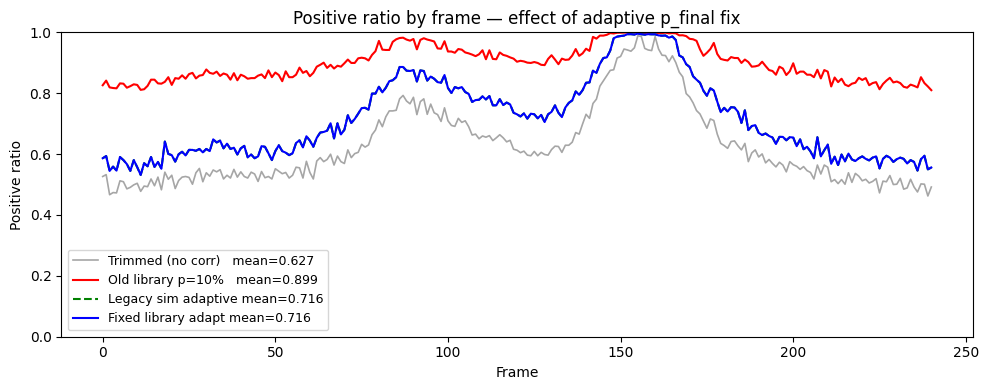

In [14]:
import importlib
import molass.Baseline.LpmBaseline as _lpm_mod
importlib.reload(_lpm_mod)
from molass.Baseline.LpmBaseline import compute_lpm_baseline

# Compute fixed 2D baseline row-by-row using adaptive p_final
print(f"Computing fixed baseline for {trimmed.xr.M.shape[0]} q-rows ...")
baseline_fixed_full = np.array([
    compute_lpm_baseline(jv, trimmed.xr.M[qi, :], size_sigma=size_sigma_fixed)
    for qi in range(trimmed.xr.M.shape[0])
])
M_fixed_corr = trimmed.xr.M - baseline_fixed_full
ratios_fixed = compute_ratios_for_matrix(M_fixed_corr)

# Summary table
print(f"\n{'Condition':<35} {'mean':>6}  {'min':>6}  {'max':>6}")
print("-" * 57)
for label, ratios in [
    ("Trimmed (no correction)",    ratios_trimmed),
    ("Old library (p_final=10%)",  ratios_corrected),
    ("Legacy simulation (adaptive)", ratios_legacy_sim),
    ("Fixed library (adaptive)",   ratios_fixed),
]:
    print(f"{label:<35} {ratios.mean():>6.3f}  {ratios.min():>6.3f}  {ratios.max():>6.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frames, ratios_trimmed,    label=f'Trimmed (no corr)   mean={ratios_trimmed.mean():.3f}',    color='gray',  lw=1.2, alpha=0.7)
ax.plot(frames, ratios_corrected,  label=f'Old library p=10%   mean={ratios_corrected.mean():.3f}',  color='red',   lw=1.5)
ax.plot(frames, ratios_legacy_sim, label=f'Legacy sim adaptive mean={ratios_legacy_sim.mean():.3f}', color='green', lw=1.5, linestyle='--')
ax.plot(frames, ratios_fixed,      label=f'Fixed library adapt mean={ratios_fixed.mean():.3f}',      color='blue',  lw=1.5)
ax.set_xlabel('Frame')
ax.set_ylabel('Positive ratio')
ax.set_title('Positive ratio by frame — effect of adaptive p_final fix')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Cell 24: Buffer-mask polyfit — can we do better than adaptive p_final?

**Idea**: instead of guessing `p_final` from per-row noisiness, use the summed elution (high-SNR) to classify buffer frames directly, then anchor the linear fit on those frames only via `np.polyfit`.

- Buffer mask: `elution_norm < threshold` (e.g. 0.10 → frames where sample signal < 10% of peak)
- Per q-row fit: `slope, intercept = np.polyfit(x[buffer], y[buffer], 1)`
- No iterative percentile descent needed — direct closed-form solution
- Try several thresholds to assess sensitivity

Buffer frame count by threshold:
  threshold=0.05: 144/241 buffer frames  →  mean positive_ratio = 0.598
  threshold=0.10: 164/241 buffer frames  →  mean positive_ratio = 0.578
  threshold=0.15: 173/241 buffer frames  →  mean positive_ratio = 0.565
  threshold=0.20: 182/241 buffer frames  →  mean positive_ratio = 0.551

Condition                                  mean     min     max
------------------------------------------------------------
Trimmed (no correction)                   0.627   0.462   0.989
Old library (p_final=10%)                 0.899   0.810   1.000
Legacy / Fixed (adaptive pf)              0.716   0.532   0.996
  Buffer-mask polyfit (thr=0.05)     0.598   0.396   0.989
  Buffer-mask polyfit (thr=0.10)     0.578   0.365   0.989
  Buffer-mask polyfit (thr=0.15)     0.565   0.354   0.989
  Buffer-mask polyfit (thr=0.20)     0.551   0.346   0.989


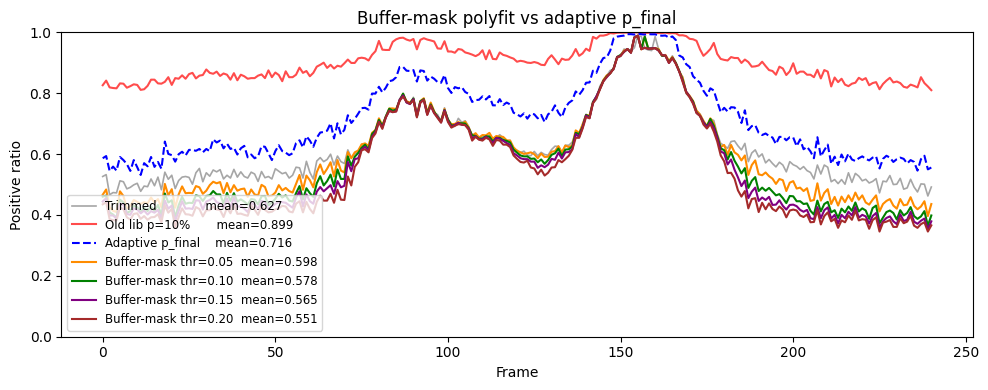

In [15]:
def lpm_bufmask(x, y, buffer_mask):
    """Linear fit anchored on buffer frames only."""
    slope, intercept = np.polyfit(x[buffer_mask], y[buffer_mask], 1)
    return x * slope + intercept

def compute_baseline_bufmask(M, x, buffer_mask):
    return np.array([lpm_bufmask(x, M[qi, :], buffer_mask) for qi in range(M.shape[0])])

# elution_norm is already in scope from cell 5 (XR elution normalised to peak=1)
print(f"Buffer frame count by threshold:")
thresholds = [0.05, 0.10, 0.15, 0.20]
results = {}
for thr in thresholds:
    buf = elution_norm < thr
    n_buf = buf.sum()
    M_corr = trimmed.xr.M - compute_baseline_bufmask(trimmed.xr.M, jv, buf)
    ratios = compute_ratios_for_matrix(M_corr)
    results[thr] = ratios
    print(f"  threshold={thr:.2f}: {n_buf}/{len(jv)} buffer frames  →  mean positive_ratio = {ratios.mean():.3f}")

# Summary table vs all previous methods
print(f"\n{'Condition':<40} {'mean':>6}  {'min':>6}  {'max':>6}")
print("-" * 60)
for label, ratios in [
    ("Trimmed (no correction)",        ratios_trimmed),
    ("Old library (p_final=10%)",      ratios_corrected),
    ("Legacy / Fixed (adaptive pf)",   ratios_fixed),
]:
    print(f"{label:<40} {ratios.mean():>6.3f}  {ratios.min():>6.3f}  {ratios.max():>6.3f}")
for thr, ratios in results.items():
    print(f"  Buffer-mask polyfit (thr={thr:.2f})    {ratios.mean():>6.3f}  {ratios.min():>6.3f}  {ratios.max():>6.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(frames, ratios_trimmed,  label=f'Trimmed             mean={ratios_trimmed.mean():.3f}', color='gray',   lw=1.2, alpha=0.7)
ax.plot(frames, ratios_corrected,label=f'Old lib p=10%       mean={ratios_corrected.mean():.3f}',color='red',   lw=1.5, alpha=0.7)
ax.plot(frames, ratios_fixed,    label=f'Adaptive p_final    mean={ratios_fixed.mean():.3f}',    color='blue',  lw=1.5, linestyle='--')
colors = ['darkorange', 'green', 'purple', 'brown']
for (thr, ratios), col in zip(results.items(), colors):
    ax.plot(frames, ratios, label=f'Buffer-mask thr={thr:.2f}  mean={ratios.mean():.3f}', color=col, lw=1.5)
ax.set_xlabel('Frame')
ax.set_ylabel('Positive ratio')
ax.set_title('Buffer-mask polyfit vs adaptive p_final')
ax.legend(loc='lower left', fontsize=8.5)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## Cell 25: Multi-dataset verification — bufmask superiority across 7 datasets

Verify that the bufmask baseline method consistently outperforms the adaptive p_final (LPM linear) method across:
- **SAMPLE1–SAMPLE4** from `molass_data` (standard test datasets bundled with the library)
- **Apo, ATP, MY** from `DATA_ROOT` (Shimizu 20260305 experimental datasets)

- `ratio_linear` = mean positive_ratio after linear (LPM adaptive p_final) baseline correction  
- `ratio_bufmask` = mean positive_ratio after buffer-mask polyfit baseline correction  
- **Acceptance criterion**: `ratio_bufmask < ratio_linear` for every dataset (closer to 0.5 = better)

In [5]:
import os
from molass_data import SAMPLE1, SAMPLE2, SAMPLE3, SAMPLE4
from molass.DataObjects import SecSaxsData as SSD

DATA_ROOT = r"C:\Users\takahashi\Dropbox\MOLASS\DATA\20260305"

datasets = [
    ('SAMPLE1', 'molass_data', str(SAMPLE1)),
    ('SAMPLE2', 'molass_data', str(SAMPLE2)),
    ('SAMPLE3', 'molass_data', str(SAMPLE3)),
    ('SAMPLE4', 'molass_data', str(SAMPLE4)),
    ('Apo',    'Shimizu',     os.path.join(DATA_ROOT, 'Apo')),
    ('ATP',    'Shimizu',     os.path.join(DATA_ROOT, 'ATP')),
    ('MY',     'Shimizu',     os.path.join(DATA_ROOT, 'MY')),
]

results = []
print("Computing ... (this may take ~30 s)")
for name, source, path in datasets:
    ssd = SSD(path)
    xr = ssd.trimmed_copy().xr

    # Linear baseline (LPM adaptive p_final)
    xr.baseline_method = 'linear'
    baseline_lin = xr.get_baseline2d()
    ratio_linear = compute_ratios_for_matrix(xr.M - baseline_lin).mean()

    # Bufmask baseline (buffer-mask polyfit)
    xr.baseline_method = 'bufmask'
    baseline_buf = xr.get_baseline2d()
    ratio_bufmask = compute_ratios_for_matrix(xr.M - baseline_buf).mean()

    improvement = ratio_linear - ratio_bufmask
    results.append((name, source, ratio_linear, ratio_bufmask, improvement))
    print(f"  {name:<8} ({source:<11}): linear={ratio_linear:.3f}  bufmask={ratio_bufmask:.3f}  Δ={improvement:+.3f}")

print(f"\n{'Dataset':<10} {'Source':<12} {'ratio_linear':>12} {'ratio_bufmask':>13} {'improvement':>11}")
print("-" * 62)
for name, source, ratio_linear, ratio_bufmask, improvement in results:
    marker = "✅" if improvement > 0 else "❌"
    print(f"{name:<10} {source:<12} {ratio_linear:>12.3f} {ratio_bufmask:>13.3f} {improvement:>+11.3f}  {marker}")

all_better = all(r[4] > 0 for r in results)
print(f"\nbufmask < linear for all datasets: {'✅ YES' if all_better else '❌ NO (see ❌ rows)'}")


Computing ... (this may take ~30 s)


zeros at the angular ends of error data have been replaced with the adjacent values.


  SAMPLE1  (molass_data): linear=0.716  bufmask=0.578  Δ=+0.138
  SAMPLE2  (molass_data): linear=0.639  bufmask=0.546  Δ=+0.092
  SAMPLE3  (molass_data): linear=0.702  bufmask=0.561  Δ=+0.140
  SAMPLE4  (molass_data): linear=0.702  bufmask=0.600  Δ=+0.103
  Apo      (Shimizu    ): linear=0.637  bufmask=0.556  Δ=+0.081
  ATP      (Shimizu    ): linear=0.642  bufmask=0.541  Δ=+0.101


zeros at the angular ends of error data have been replaced with the adjacent values.


  MY       (Shimizu    ): linear=0.987  bufmask=0.529  Δ=+0.458

Dataset    Source       ratio_linear ratio_bufmask improvement
--------------------------------------------------------------
SAMPLE1    molass_data         0.716         0.578      +0.138  ✅
SAMPLE2    molass_data         0.639         0.546      +0.092  ✅
SAMPLE3    molass_data         0.702         0.561      +0.140  ✅
SAMPLE4    molass_data         0.702         0.600      +0.103  ✅
Apo        Shimizu             0.637         0.556      +0.081  ✅
ATP        Shimizu             0.642         0.541      +0.101  ✅
MY         Shimizu             0.987         0.529      +0.458  ✅

bufmask < linear for all datasets: ✅ YES
